# Research & Student Growth — Year-by-Year Analysis

This notebook combines four datasets and analyzes year-by-year relationships:

1. **Research Projects** by grant type (External, Internal, Strategic, Joint, National Research) — counts and allocated funding
2. **Research Papers** published in journals and presented in conferences
3. **Undergraduate Students** (Diploma / Bachelor — Admitted, Registered, Graduated, by gender)
4. **Postgraduate Students** (PG Diploma / Masters / Doctorates — Admitted, Registered, Graduated, by gender)

Goal: build one master year-indexed table, visualize trends, and quantify how research output relates to student populations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

DOWNLOADS = r'C:\Users\User\Downloads'
PROJECTS_FILE = fr'{DOWNLOADS}\Growth in the number of research projects by various types of grants.xlsx'
PAPERS_FILE   = fr'{DOWNLOADS}\Growth in number of research papers published in Journals and presented in conferences.xlsx'
UG_FILE       = fr'{DOWNLOADS}\Growth of Undergraduate students.xlsx'
PG_FILE       = fr'{DOWNLOADS}\Growth of postgraduate students.xlsx'

## 1. Load & clean each dataset

### 1a. Research projects by grant type

In [2]:
projects_raw = pd.read_excel(PROJECTS_FILE, sheet_name='Number of  Projects')
projects_raw.columns = [c.strip().replace('\n', ' ') for c in projects_raw.columns]
projects_raw = projects_raw.rename(columns={
    'Number of  Projects': 'Projects',
    'Amount Allocated (Omani Rials)': 'Amount_OMR',
})
projects_raw['Year'] = projects_raw['Year'].astype(int)
projects_raw['Projects'] = projects_raw['Projects'].astype(int)
projects_raw['Amount_OMR'] = projects_raw['Amount_OMR'].astype(float)
print(projects_raw.shape)
projects_raw.head()

(125, 4)


,Year,Grants,Projects,Amount_OMR
0,2025,External,9,108611.0
1,2024,External,1,7640.0
2,2023,External,2,21600.0
3,2022,External,2,40000.0
4,2021,External,6,143548.0


In [3]:
# Pivot: one row per Year, columns by Grant type
projects_by_grant = (projects_raw
                     .pivot_table(index='Year', columns='Grants', values='Projects', aggfunc='sum')
                     .fillna(0).astype(int))
projects_by_grant.columns = [f'Projects_{c}' for c in projects_by_grant.columns]
funding_by_grant = (projects_raw
                    .pivot_table(index='Year', columns='Grants', values='Amount_OMR', aggfunc='sum')
                    .fillna(0))
funding_by_grant.columns = [f'Funding_{c}_OMR' for c in funding_by_grant.columns]

projects_year = projects_by_grant.copy()
projects_year['Total_Projects'] = projects_year.sum(axis=1)
funding_year = funding_by_grant.copy()
funding_year['Total_Funding_OMR'] = funding_year.sum(axis=1)

projects_year.join(funding_year[['Total_Funding_OMR']]).tail(10)

,Projects_External,Projects_Internal,Projects_Joint,Projects_National Research,Projects_Strategic,Total_Projects,Total_Funding_OMR
Year,,,,,,,
2016,2,84,7,5,5,103,1846319.0
2017,9,88,4,1,7,109,1344331.0
2018,5,119,12,11,6,153,2241173.0
2019,4,100,0,67,7,178,1632458.0
2020,17,97,6,33,7,160,1775728.0
2021,6,91,4,54,7,162,1563485.0
2022,2,105,5,40,5,157,1148606.4
2023,2,118,8,44,9,181,1608410.0
2024,1,129,9,81,7,227,1810174.0


### 1b. Research papers (journals + conferences)

In [4]:
papers_raw = pd.read_excel(PAPERS_FILE, sheet_name='No. of research papers')
papers_raw.columns = [c.strip() for c in papers_raw.columns]
papers_raw['Year'] = papers_raw['Year'].astype(int)
papers_raw['Number'] = papers_raw['Number'].astype(int)

# Two categories: journals & conferences
papers_raw['Category'] = papers_raw['No. of research papers'].map({
    'No. of research papers published in journals': 'Journals',
    'No. of research papers presented in conferences': 'Conferences',
})
papers_year = (papers_raw.pivot_table(index='Year', columns='Category', values='Number', aggfunc='sum')
               .fillna(0).astype(int))
papers_year.columns = [f'Papers_{c}' for c in papers_year.columns]
papers_year['Papers_Total'] = papers_year.sum(axis=1)
papers_year.tail(10)

,Papers_Conferences,Papers_Journals,Papers_Total
Year,,,
2016,733,1250,1983
2017,568,1043,1611
2018,245,193,438
2019,229,1568,1797
2020,518,1615,2133
2021,72,1554,1626
2022,244,1794,2038
2023,284,1491,1775
2024,267,1475,1742


### 1c. Undergraduate students

Academic years like `2000-2001` are mapped to the **ending year** (2001) so they align with the calendar-year project/paper datasets.

In [5]:
ug_raw = pd.read_excel(UG_FILE, sheet_name='Growth of Undergraduate')
ug_raw.columns = [c.strip() for c in ug_raw.columns]
ug_raw['Year'] = ug_raw['Academic Year'].str.split('-').str[1].astype(int)
ug_raw['Total'] = ug_raw['Total'].astype(int)
print(ug_raw.shape)
ug_raw.head()

(312, 6)


,Academic Year,Students Status,Qualification,Gender,Total,Year
0,2025-2026,Admitted,Diploma,Male,0,2026
1,2025-2026,Admitted,Diploma,Female,0,2026
2,2025-2026,Admitted,Bachelor,Male,1675,2026
3,2025-2026,Admitted,Bachelor,Female,1499,2026
4,2025-2026,Registered,Diploma,Male,0,2026


In [6]:
# Year-level aggregates: by status, by status+qualification, by gender
ug_status = (ug_raw.pivot_table(index='Year', columns='Students Status', values='Total', aggfunc='sum')
             .fillna(0).astype(int))
ug_status.columns = [f'UG_{c}' for c in ug_status.columns]

ug_gender = (ug_raw.pivot_table(index='Year', columns='Gender', values='Total', aggfunc='sum')
             .fillna(0).astype(int))
ug_gender.columns = [f'UG_{c}' for c in ug_gender.columns]

ug_year = ug_status.join(ug_gender)
ug_year['UG_Total'] = ug_year[[c for c in ug_status.columns]].sum(axis=1)
ug_year.tail(10)

,UG_Admitted,UG_Graduated,UG_Registered,UG_Female,UG_Male,UG_Total
Year,,,,,,
2017,3028,2436,16125,11726,9863,21589
2018,3007,2757,15878,11645,9997,21642
2019,2984,2512,15840,11348,9988,21336
2020,3114,2502,16018,11360,10274,21634
2021,3177,2530,16353,11395,10665,22060
2022,3145,2194,16931,11374,10896,22270
2023,3088,2423,17113,11360,11264,22624
2024,3067,2467,17156,11184,11506,22690
2025,3095,2584,17188,11200,11667,22867


### 1d. Postgraduate students

In [7]:
pg_raw = pd.read_excel(PG_FILE, sheet_name='Growth od Postgraduate')
pg_raw.columns = [c.strip() for c in pg_raw.columns]
pg_raw = pg_raw.rename(columns={'Students status': 'Students Status'})
pg_raw['Year'] = pg_raw['Academic Year'].str.split('-').str[1].astype(int)
pg_raw['Total'] = pg_raw['Total'].astype(int)

pg_status = (pg_raw.pivot_table(index='Year', columns='Students Status', values='Total', aggfunc='sum')
             .fillna(0).astype(int))
pg_status.columns = [f'PG_{c}' for c in pg_status.columns]

pg_qual = (pg_raw[pg_raw['Students Status'] == 'Registered']
           .pivot_table(index='Year', columns='Qualification', values='Total', aggfunc='sum')
           .fillna(0).astype(int))
pg_qual.columns = [f'PG_Reg_{c.replace(" ", "_")}' for c in pg_qual.columns]

pg_year = pg_status.join(pg_qual)
pg_year['PG_Total'] = pg_year[[c for c in pg_status.columns]].sum(axis=1)
pg_year.tail(10)

,PG_Admitted,PG_Graduated,PG_Registered,PG_Reg_Doctorates,PG_Reg_Masters,PG_Reg_Postgraduate_Diploma,PG_Total
Year,,,,,,,
2017,974,453,1665,198,1347,120,3092
2018,1073,566,1652,218,1257,177,3291
2019,1086,577,1757,232,1331,194,3420
2020,1177,587,1936,266,1479,191,3700
2021,1208,585,2013,272,1533,208,3806
2022,1152,718,1899,299,1396,204,3769
2023,1209,672,1745,295,1259,191,3626
2024,1414,633,2209,362,1626,221,4256
2025,1234,709,2248,399,1617,232,4191


## 2. Master year-indexed table

All four datasets joined on `Year`. This is the central artifact for every later analysis.

In [8]:
master = (projects_year
          .join(funding_year, how='outer')
          .join(papers_year, how='outer')
          .join(ug_year, how='outer')
          .join(pg_year, how='outer')
          .sort_index())
master.index.name = 'Year'
print('Years covered:', master.index.min(), '→', master.index.max(), f'({len(master)} years)')
print('Columns:', master.shape[1])
master.tail(10)

Years covered: 2001 → 2026 (26 years)
Columns: 28


,Projects_External,Projects_Internal,Projects_Joint,Projects_National Research,Projects_Strategic,Total_Projects,Funding_External_OMR,Funding_Internal_OMR,Funding_Joint_OMR,Funding_National Research_OMR,Funding_Strategic_OMR,Total_Funding_OMR,Papers_Conferences,Papers_Journals,Papers_Total,UG_Admitted,UG_Graduated,UG_Registered,UG_Female,UG_Male,UG_Total,PG_Admitted,PG_Graduated,PG_Registered,PG_Reg_Doctorates,PG_Reg_Masters,PG_Reg_Postgraduate_Diploma,PG_Total
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017,9.0,88.0,4.0,1.0,7.0,109.0,167169.0,458176.0,63386.0,221600.0,434000.0,1344331.0,568.0,1043.0,1611.0,3028,2436,16125,11726,9863,21589,974,453,1665,198,1347,120,3092
2018,5.0,119.0,12.0,11.0,6.0,153.0,1143673.0,533500.0,110600.0,23400.0,430000.0,2241173.0,245.0,193.0,438.0,3007,2757,15878,11645,9997,21642,1073,566,1652,218,1257,177,3291
2019,4.0,100.0,0.0,67.0,7.0,178.0,20400.0,438960.0,0.0,739648.0,433450.0,1632458.0,229.0,1568.0,1797.0,2984,2512,15840,11348,9988,21336,1086,577,1757,232,1331,194,3420
2020,17.0,97.0,6.0,33.0,7.0,160.0,348367.0,479050.0,161450.0,347861.0,439000.0,1775728.0,518.0,1615.0,2133.0,3114,2502,16018,11360,10274,21634,1177,587,1936,266,1479,191,3700
2021,6.0,91.0,4.0,54.0,7.0,162.0,143548.0,451944.0,114900.0,415893.0,437200.0,1563485.0,72.0,1554.0,1626.0,3177,2530,16353,11395,10665,22060,1208,585,2013,272,1533,208,3806
2022,2.0,105.0,5.0,40.0,5.0,157.0,40000.0,467010.0,141200.0,316696.4,183700.0,1148606.4,244.0,1794.0,2038.0,3145,2194,16931,11374,10896,22270,1152,718,1899,299,1396,204,3769
2023,2.0,118.0,8.0,44.0,9.0,181.0,21600.0,643100.0,186500.0,339760.0,417450.0,1608410.0,284.0,1491.0,1775.0,3088,2423,17113,11360,11264,22624,1209,672,1745,295,1259,191,3626
2024,1.0,129.0,9.0,81.0,7.0,227.0,7640.0,659570.0,234314.0,616060.0,292590.0,1810174.0,267.0,1475.0,1742.0,3067,2467,17156,11184,11506,22690,1414,633,2209,362,1626,221,4256
2025,9.0,149.0,10.0,88.0,10.0,266.0,108611.0,674195.0,207600.0,933198.0,415500.0,2339104.0,275.0,0.0,275.0,3095,2584,17188,11200,11667,22867,1234,709,2248,399,1617,232,4191


In [9]:
# Headline yearly summary (the five high-level KPIs)
summary = master[['Total_Projects', 'Total_Funding_OMR', 'Papers_Total',
                  'UG_Registered', 'PG_Registered']].copy()
summary.columns = ['Projects', 'Funding (OMR)', 'Papers', 'UG Registered', 'PG Registered']
summary

,Projects,Funding (OMR),Papers,UG Registered,PG Registered
Year,,,,,
2001,90.0,2834368.0,694.0,8542,533
2002,104.0,2307353.0,752.0,9917,761
2003,67.0,814639.0,803.0,11055,779
2004,77.0,1037001.0,837.0,11688,749
2005,70.0,1249017.0,816.0,11962,893
2006,73.0,740235.0,1254.0,12561,934
2007,69.0,912129.0,1349.0,13483,1157
2008,78.0,946742.0,1343.0,13410,1312
2009,82.0,826377.0,1579.0,14091,1185


In [10]:
# Year-over-year growth (%) for the headline KPIs
growth = summary.pct_change().mul(100).round(1)
growth.columns = [f'{c} YoY%' for c in growth.columns]
growth.tail(15)

,Projects YoY%,Funding (OMR) YoY%,Papers YoY%,UG Registered YoY%,PG Registered YoY%
Year,,,,,
2012,-9.2,46.6,55.9,4.4,3.7
2013,-6.1,-15.2,11.4,3.3,2.4
2014,26.9,39.7,-14.6,2.6,8.5
2015,-21.2,-12.1,-30.9,3.7,3.3
2016,10.8,-49.2,108.1,-1.2,4.1
2017,5.8,-27.2,-18.8,0.0,6.5
2018,40.4,66.7,-72.8,-1.5,-0.8
2019,16.3,-27.2,310.3,-0.2,6.4
2020,-10.1,8.8,18.7,1.1,10.2


## 3. Trends over time

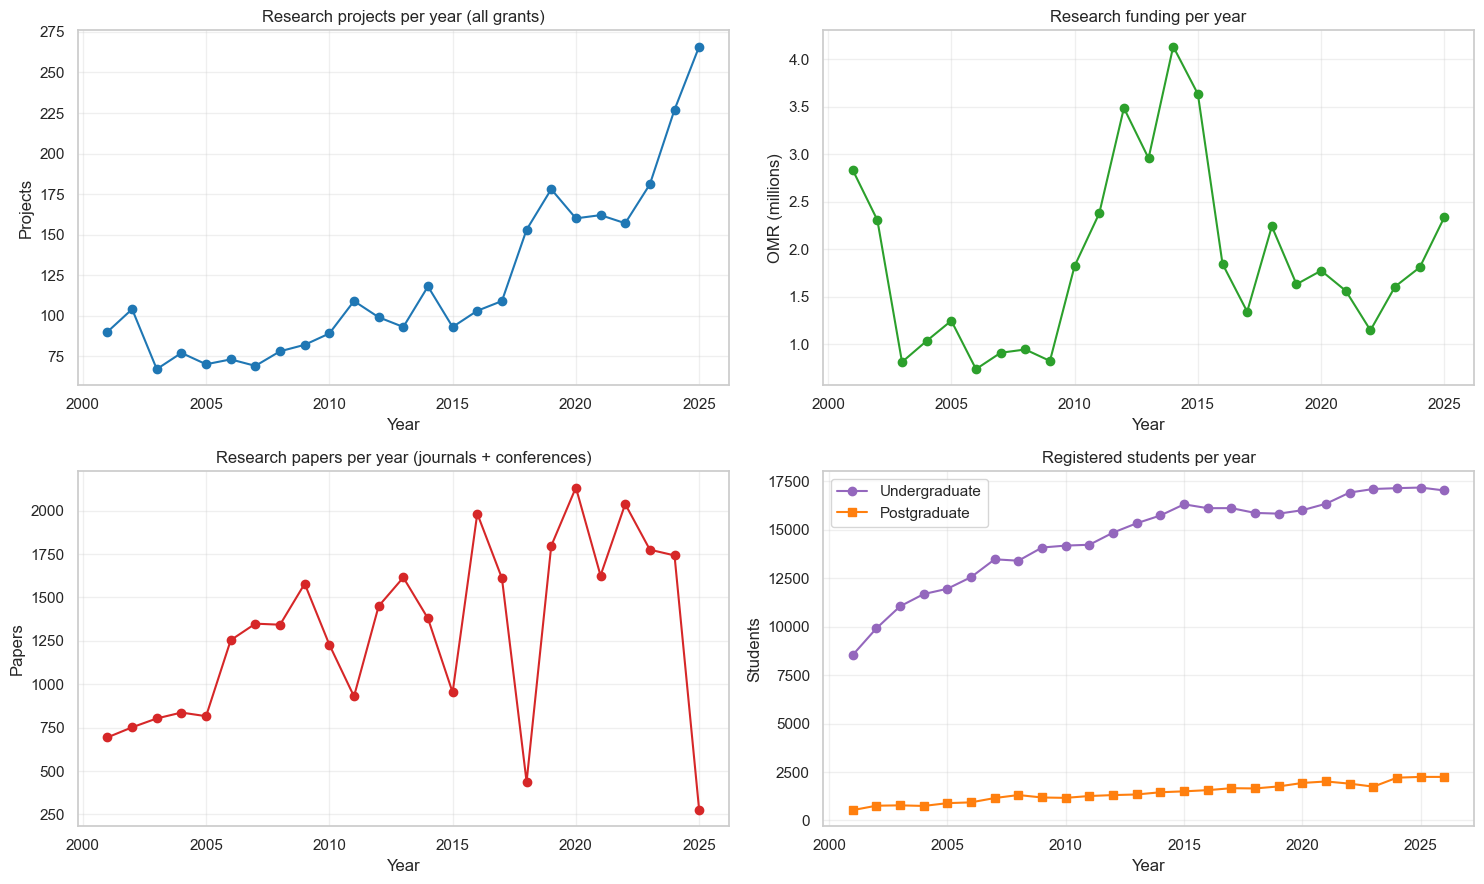

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

axes[0].plot(summary.index, summary['Projects'], marker='o', color='#1f77b4')
axes[0].set_title('Research projects per year (all grants)'); axes[0].set_ylabel('Projects')

axes[1].plot(summary.index, summary['Funding (OMR)'] / 1e6, marker='o', color='#2ca02c')
axes[1].set_title('Research funding per year'); axes[1].set_ylabel('OMR (millions)')

axes[2].plot(summary.index, summary['Papers'], marker='o', color='#d62728')
axes[2].set_title('Research papers per year (journals + conferences)'); axes[2].set_ylabel('Papers')

axes[3].plot(summary.index, summary['UG Registered'], marker='o', label='Undergraduate', color='#9467bd')
axes[3].plot(summary.index, summary['PG Registered'], marker='s', label='Postgraduate', color='#ff7f0e')
axes[3].set_title('Registered students per year'); axes[3].set_ylabel('Students'); axes[3].legend()

for ax in axes:
    ax.set_xlabel('Year'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

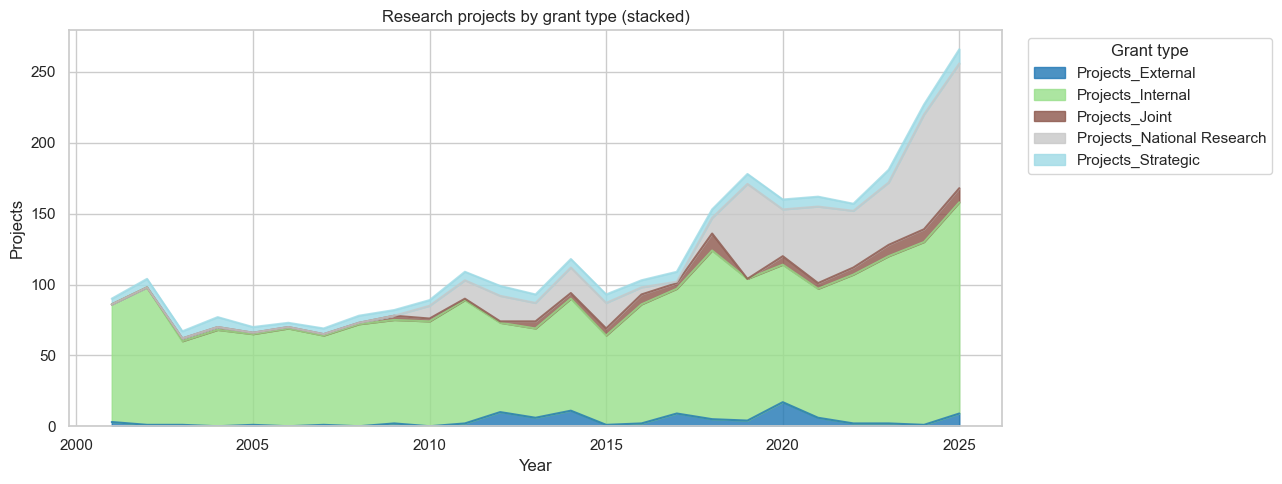

In [12]:
# Projects by grant type — stacked
grant_cols = [c for c in projects_year.columns if c.startswith('Projects_') and c != 'Total_Projects']
ax = projects_year[grant_cols].plot.area(stacked=True, alpha=0.8, figsize=(13, 5),
                                          colormap='tab20')
ax.set_title('Research projects by grant type (stacked)')
ax.set_ylabel('Projects'); ax.set_xlabel('Year')
ax.legend(title='Grant type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

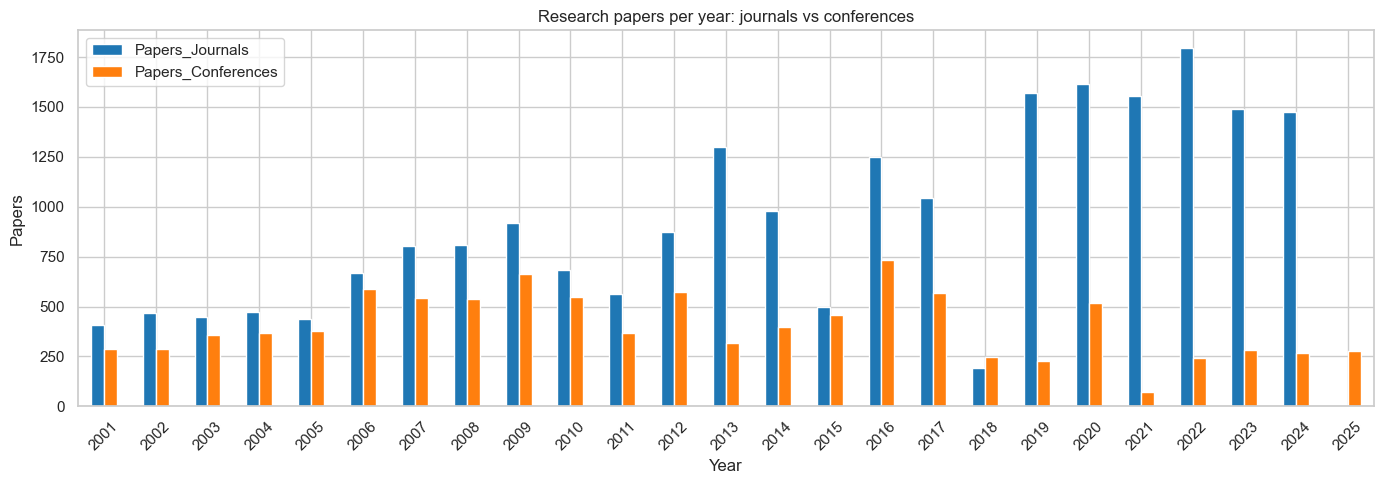

In [13]:
# Papers split: journals vs conferences
ax = papers_year[['Papers_Journals', 'Papers_Conferences']].plot.bar(
    figsize=(14, 5), color=['#1f77b4', '#ff7f0e'])
ax.set_title('Research papers per year: journals vs conferences')
ax.set_ylabel('Papers'); ax.set_xlabel('Year')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

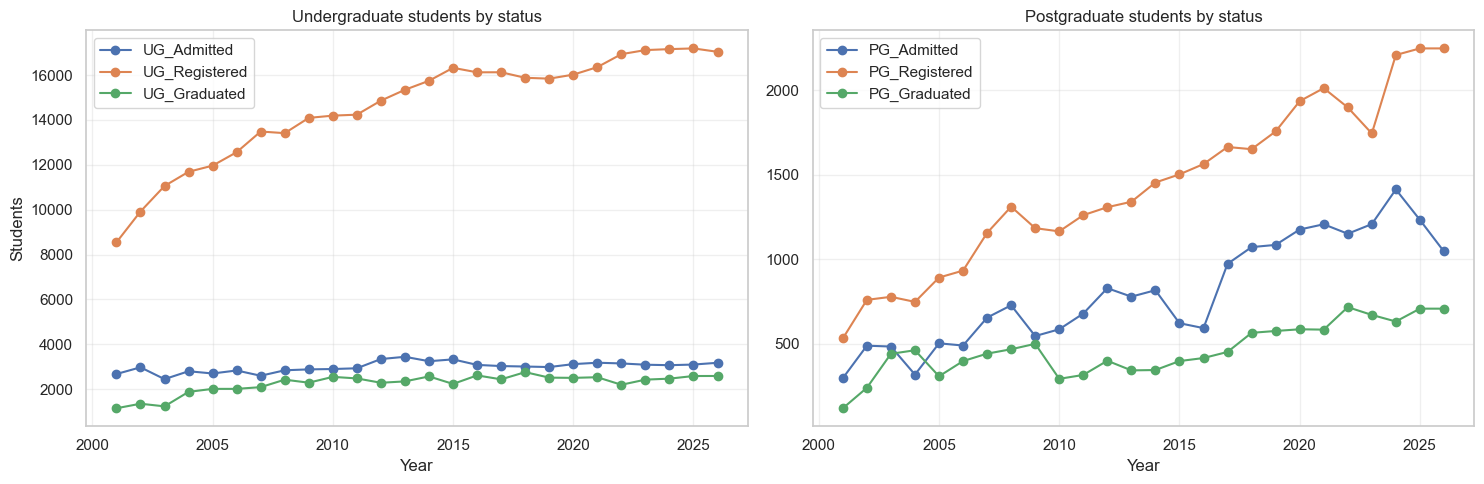

In [14]:
# Student status breakdown — UG vs PG side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ug_year[['UG_Admitted', 'UG_Registered', 'UG_Graduated']].plot(ax=axes[0], marker='o')
axes[0].set_title('Undergraduate students by status'); axes[0].set_ylabel('Students')
pg_year[['PG_Admitted', 'PG_Registered', 'PG_Graduated']].plot(ax=axes[1], marker='o')
axes[1].set_title('Postgraduate students by status')
for ax in axes:
    ax.set_xlabel('Year'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

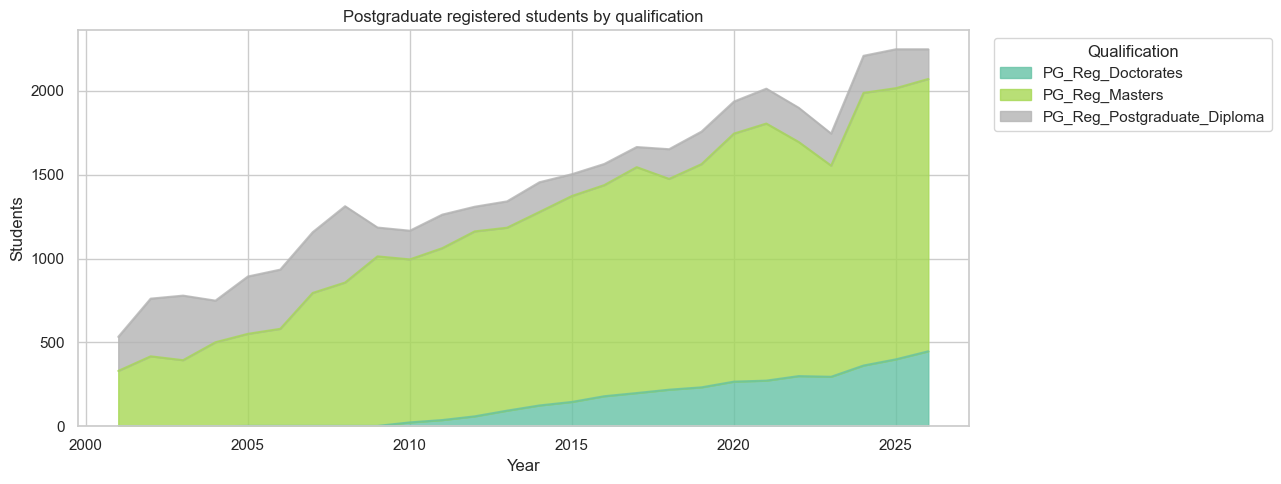

In [15]:
# PG Registered by qualification (Doctorates / Masters / PG Diploma)
qual_cols = [c for c in pg_year.columns if c.startswith('PG_Reg_')]
ax = pg_year[qual_cols].plot.area(stacked=True, alpha=0.8, figsize=(13, 5), colormap='Set2')
ax.set_title('Postgraduate registered students by qualification')
ax.set_ylabel('Students'); ax.set_xlabel('Year')
ax.legend(title='Qualification', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 4. Relationships between datasets

We now look at how research output and student population move together. Three views:

1. **Correlation heatmap** — Pearson r across the headline KPIs
2. **Scatter plots** with fitted regression line for the strongest pairs
3. **Normalized trend overlay** (each series scaled to 0–1) — visual co-movement

Years used for relationship analysis: 2001–2025 (25 years)


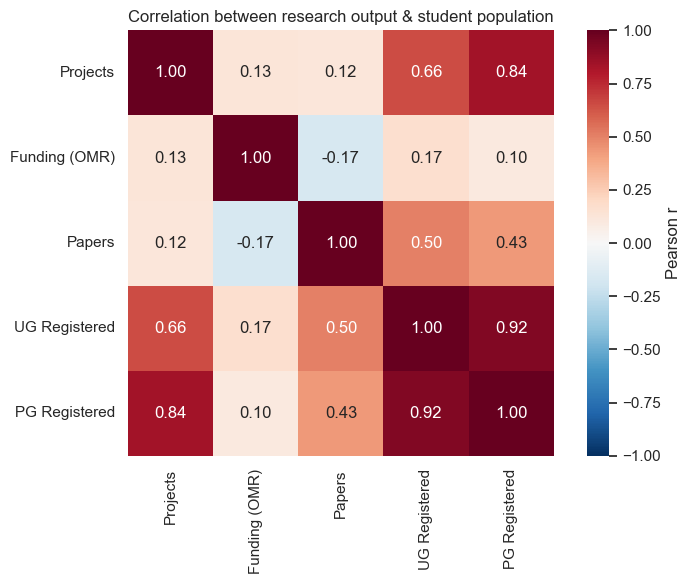

,Projects,Funding (OMR),Papers,UG Registered,PG Registered
Projects,1.00,0.13,0.12,0.66,0.84
Funding (OMR),0.13,1.00,-0.17,0.17,0.10
Papers,0.12,-0.17,1.00,0.50,0.43
UG Registered,0.66,0.17,0.50,1.00,0.92
PG Registered,0.84,0.10,0.43,0.92,1.00


In [16]:
# Use only years where every series has data, so correlations are comparable
analysis = summary.dropna()
print(f'Years used for relationship analysis: {analysis.index.min()}–{analysis.index.max()} ({len(analysis)} years)')

corr = analysis.corr(method='pearson')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation between research output & student population')
plt.tight_layout(); plt.show()
corr.round(2)

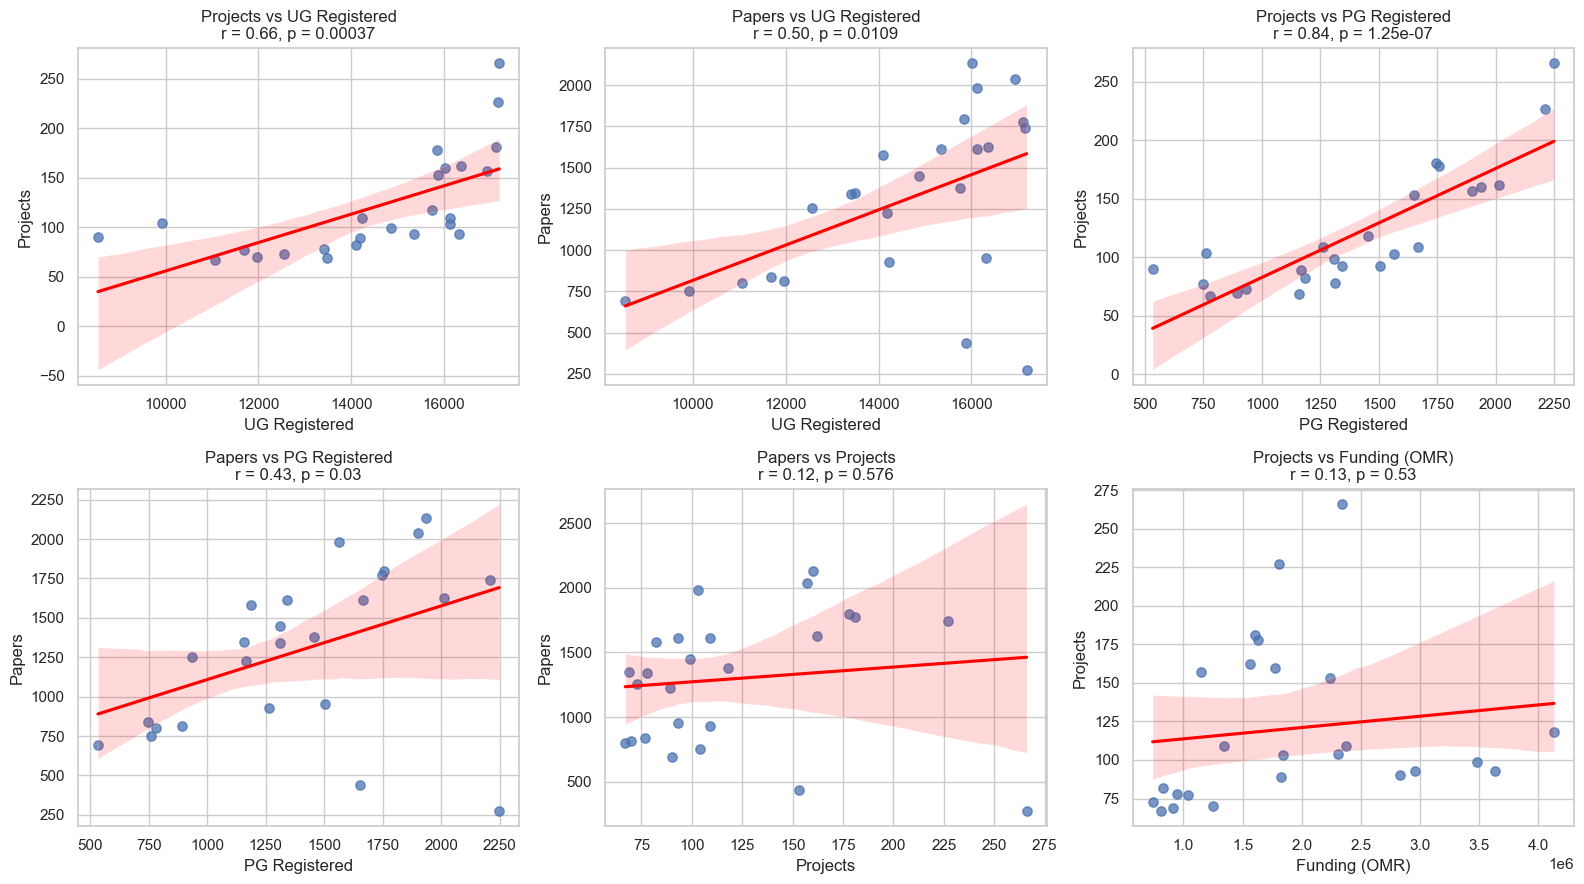

In [17]:
# Pairwise scatter with regression line + r and p-value
pairs = [
    ('UG Registered', 'Projects'),
    ('UG Registered', 'Papers'),
    ('PG Registered', 'Projects'),
    ('PG Registered', 'Papers'),
    ('Projects',      'Papers'),
    ('Funding (OMR)', 'Projects'),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (x, y) in zip(axes.flatten(), pairs):
    sub = analysis[[x, y]].dropna()
    sns.regplot(data=sub, x=x, y=y, ax=ax, scatter_kws={'s': 45, 'alpha': 0.75},
                line_kws={'color': 'red'})
    r, p = stats.pearsonr(sub[x], sub[y])
    ax.set_title(f'{y} vs {x}\nr = {r:.2f}, p = {p:.3g}')
plt.tight_layout(); plt.show()

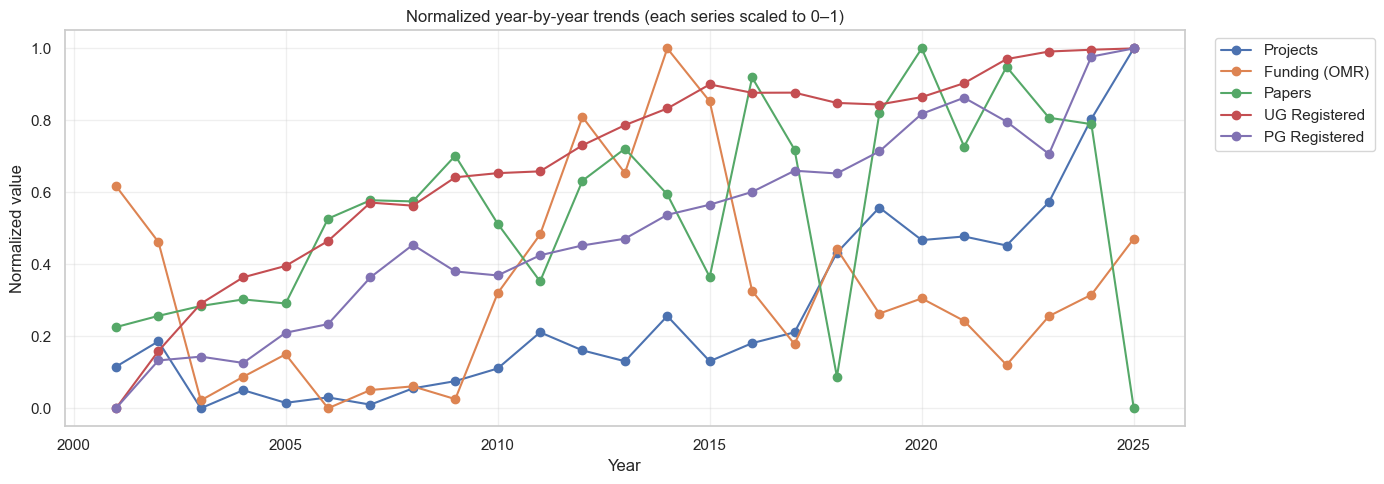

In [18]:
# Normalized trend overlay — every series scaled 0..1 to show co-movement
norm = (analysis - analysis.min()) / (analysis.max() - analysis.min())
ax = norm.plot(marker='o', figsize=(14, 5))
ax.set_title('Normalized year-by-year trends (each series scaled to 0–1)')
ax.set_ylabel('Normalized value'); ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Regression models — quantifying the relationships

For each interesting pair we fit `y = a + b·x` via OLS, report slope, R², and significance.

In [19]:
def fit_pair(df, x, y):
    sub = df[[x, y]].dropna()
    res = stats.linregress(sub[x], sub[y])
    return {
        'x': x, 'y': y, 'n': len(sub),
        'slope': res.slope,
        'intercept': res.intercept,
        'r': res.rvalue,
        'R2': res.rvalue ** 2,
        'p_value': res.pvalue,
        'std_err': res.stderr,
    }

models = [
    ('UG Registered', 'Papers'),
    ('PG Registered', 'Papers'),
    ('UG Registered', 'Projects'),
    ('PG Registered', 'Projects'),
    ('Projects',      'Papers'),
    ('Funding (OMR)', 'Projects'),
    ('Funding (OMR)', 'Papers'),
]
regression_table = pd.DataFrame([fit_pair(analysis, x, y) for x, y in models])
regression_table['significant_5%'] = regression_table['p_value'] < 0.05
regression_table.round(4)

,x,y,n,slope,intercept,r,R2,p_value,std_err,significant_5%
0,UG Registered,Papers,25,0.1067,-249.7347,0.5003,0.2503,0.0109,0.0385,True
1,PG Registered,Papers,25,0.4679,640.4284,0.4343,0.1887,0.0300,0.2023,True
2,UG Registered,Projects,25,0.0144,-87.7326,0.6560,0.4303,0.0004,0.0034,True
3,PG Registered,Projects,25,0.0932,-10.2807,0.8427,0.7102,0.0000,0.0124,True
4,Projects,Papers,25,1.1441,1158.3817,0.1174,0.0138,0.5761,2.0174,False
5,Funding (OMR),Projects,25,0.0000,106.3599,0.1319,0.0174,0.5297,0.0000,False
6,Funding (OMR),Papers,25,-0.0001,1469.3545,-0.1686,0.0284,0.4204,0.0001,False


### Lag analysis — does this year's student population predict *next* year's research?

PhDs admitted today usually publish 2-4 years later. So we also compute correlations with a 1, 2, and 3-year lag between the student population and research output.

In [20]:
def lagged_corr(df, driver, outcome, max_lag=3):
    rows = []
    for lag in range(0, max_lag + 1):
        shifted = df[[driver, outcome]].copy()
        shifted[driver] = shifted[driver].shift(lag)
        sub = shifted.dropna()
        if len(sub) < 3:
            continue
        r, p = stats.pearsonr(sub[driver], sub[outcome])
        rows.append({'driver': driver, 'outcome': outcome, 'lag_years': lag,
                     'r': round(r, 3), 'p': round(p, 4), 'n': len(sub)})
    return pd.DataFrame(rows)

lag_results = pd.concat([
    lagged_corr(analysis, 'UG Registered', 'Papers'),
    lagged_corr(analysis, 'PG Registered', 'Papers'),
    lagged_corr(analysis, 'UG Registered', 'Projects'),
    lagged_corr(analysis, 'PG Registered', 'Projects'),
], ignore_index=True)
lag_results

,driver,outcome,lag_years,r,p,n
0,UG Registered,Papers,0,0.500,0.0109,25
1,UG Registered,Papers,1,0.426,0.0377,24
2,UG Registered,Papers,2,0.361,0.0907,23
3,UG Registered,Papers,3,0.296,0.1806,22
4,PG Registered,Papers,0,0.434,0.0300,25
5,PG Registered,Papers,1,0.369,0.0762,24
6,PG Registered,Papers,2,0.430,0.0405,23
7,PG Registered,Papers,3,0.277,0.2121,22
8,UG Registered,Projects,0,0.656,0.0004,25
9,UG Registered,Projects,1,0.693,0.0002,24


## 6. Derived productivity ratios per year

- **Papers per registered student** (UG and PG)
- **Papers per project**
- **Funding per project**

In [21]:
ratios = pd.DataFrame(index=analysis.index)
ratios['Papers per 1000 UG']  = analysis['Papers'] / analysis['UG Registered'] * 1000
ratios['Papers per 100 PG']   = analysis['Papers'] / analysis['PG Registered'] * 100
ratios['Papers per Project']  = analysis['Papers'] / analysis['Projects'].replace(0, np.nan)
ratios['Funding per Project (OMR)'] = (analysis['Funding (OMR)']
                                       / analysis['Projects'].replace(0, np.nan))
ratios.round(2)

,Papers per 1000 UG,Papers per 100 PG,Papers per Project,Funding per Project (OMR)
Year,,,,
2001,81.25,130.21,7.71,31492.98
2002,75.83,98.82,7.23,22186.09
2003,72.64,103.08,11.99,12158.79
2004,71.61,111.75,10.87,13467.55
2005,68.22,91.38,11.66,17843.10
2006,99.83,134.26,17.18,10140.21
2007,100.05,116.59,19.55,13219.26
2008,100.15,102.36,17.22,12137.72
2009,112.06,133.25,19.26,10077.77


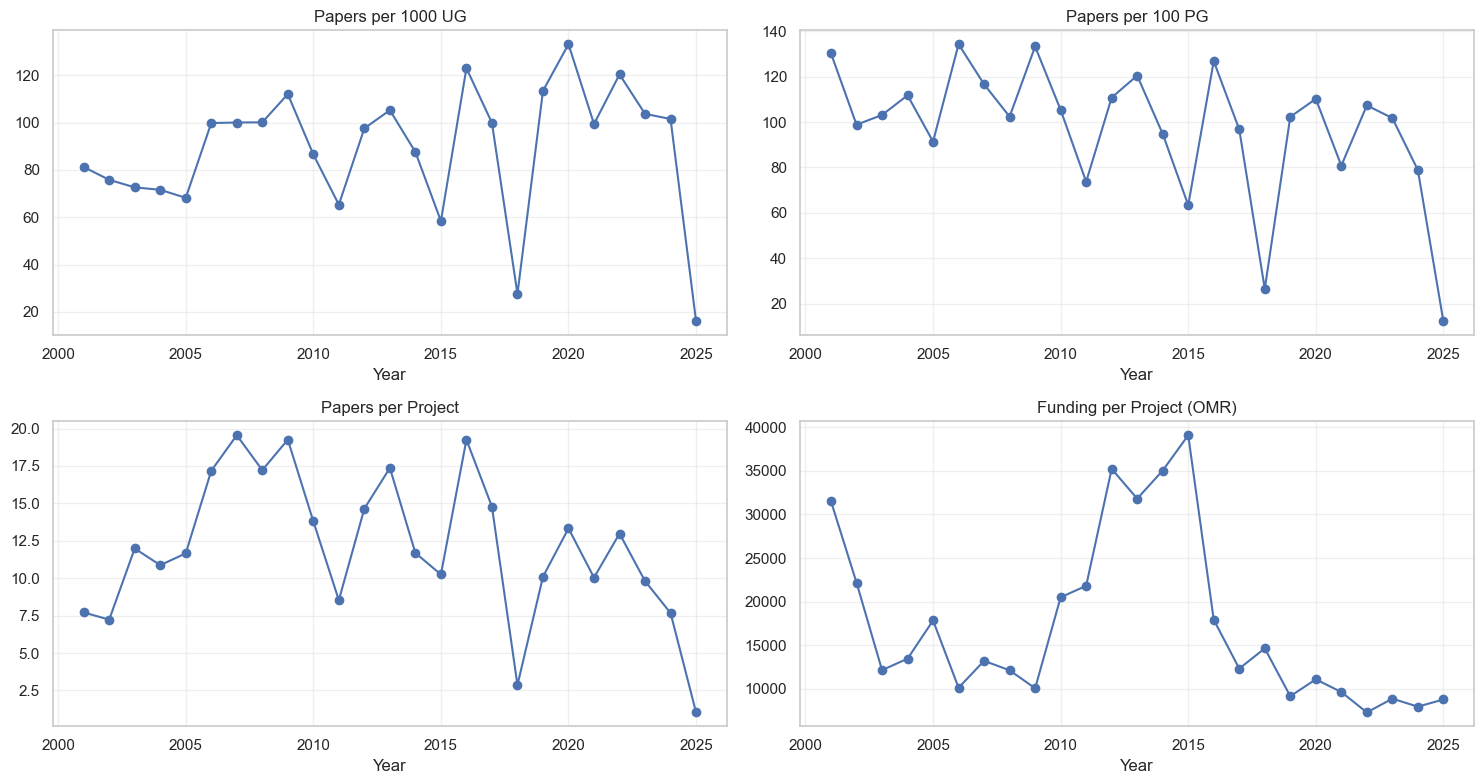

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ratios.columns):
    ax.plot(ratios.index, ratios[col], marker='o')
    ax.set_title(col); ax.set_xlabel('Year'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Per-year diagnostic table (everything in one place)

The combined annual snapshot — useful for the report appendix.

In [23]:
snapshot = analysis.join(ratios).round(2)
snapshot.to_csv(r'C:\Users\User\Desktop\ALYAMAMA\yearly_snapshot.csv')
print('Saved → yearly_snapshot.csv')
snapshot

Saved → yearly_snapshot.csv


,Projects,Funding (OMR),Papers,UG Registered,PG Registered,Papers per 1000 UG,Papers per 100 PG,Papers per Project,Funding per Project (OMR)
Year,,,,,,,,,
2001,90.0,2834368.0,694.0,8542,533,81.25,130.21,7.71,31492.98
2002,104.0,2307353.0,752.0,9917,761,75.83,98.82,7.23,22186.09
2003,67.0,814639.0,803.0,11055,779,72.64,103.08,11.99,12158.79
2004,77.0,1037001.0,837.0,11688,749,71.61,111.75,10.87,13467.55
2005,70.0,1249017.0,816.0,11962,893,68.22,91.38,11.66,17843.10
2006,73.0,740235.0,1254.0,12561,934,99.83,134.26,17.18,10140.21
2007,69.0,912129.0,1349.0,13483,1157,100.05,116.59,19.55,13219.26
2008,78.0,946742.0,1343.0,13410,1312,100.15,102.36,17.22,12137.72
2009,82.0,826377.0,1579.0,14091,1185,112.06,133.25,19.26,10077.77


## 8. Findings (auto-generated summary)

In [24]:
def trend(series):
    s = series.dropna()
    first, last = s.iloc[0], s.iloc[-1]
    pct = (last - first) / first * 100 if first else float('nan')
    return first, last, pct

lines = []
for label, col in [('Projects (total/yr)', 'Projects'),
                   ('Funding (OMR/yr)',    'Funding (OMR)'),
                   ('Papers (total/yr)',   'Papers'),
                   ('UG Registered',       'UG Registered'),
                   ('PG Registered',       'PG Registered')]:
    f, l, p = trend(analysis[col])
    lines.append(f'  • {label:25s}  {analysis.index.min()}: {f:>12,.0f}   →   {analysis.index.max()}: {l:>12,.0f}   ({p:+.0f}%)')

print(f'Window analysed: {analysis.index.min()}–{analysis.index.max()}  ({len(analysis)} years)')
print('\nFirst vs latest year:')
print('\n'.join(lines))

print('\nStrongest positive relationships (Pearson r ≥ 0.5, p < 0.05):')
strong = regression_table[(regression_table['r'] >= 0.5) & (regression_table['p_value'] < 0.05)] \
    .sort_values('r', ascending=False)
for _, row in strong.iterrows():
    print(f'  • {row["y"]:14s} ~ {row["x"]:14s}   r={row["r"]:+.2f}   R²={row["R2"]:.2f}   p={row["p_value"]:.3g}   n={int(row["n"])}')

print('\nStrongest negative relationships (Pearson r ≤ -0.5, p < 0.05):')
neg = regression_table[(regression_table['r'] <= -0.5) & (regression_table['p_value'] < 0.05)] \
    .sort_values('r')
if len(neg) == 0:
    print('  (none)')
else:
    for _, row in neg.iterrows():
        print(f'  • {row["y"]:14s} ~ {row["x"]:14s}   r={row["r"]:+.2f}   R²={row["R2"]:.2f}   p={row["p_value"]:.3g}   n={int(row["n"])}')

print('\nBest predictive lag (driver → outcome):')
best_lag = lag_results.loc[lag_results.groupby(['driver', 'outcome'])['r'].idxmax()]
for _, row in best_lag.iterrows():
    print(f'  • {row["driver"]:14s} → {row["outcome"]:9s}  best lag = {int(row["lag_years"])} yr   r={row["r"]:+.2f}   p={row["p"]:.3g}')

Window analysed: 2001–2025  (25 years)

First vs latest year:
  • Projects (total/yr)        2001:           90   →   2025:          266   (+196%)
  • Funding (OMR/yr)           2001:    2,834,368   →   2025:    2,339,104   (-17%)
  • Papers (total/yr)          2001:          694   →   2025:          275   (-60%)
  • UG Registered              2001:        8,542   →   2025:       17,188   (+101%)
  • PG Registered              2001:          533   →   2025:        2,248   (+322%)

Strongest positive relationships (Pearson r ≥ 0.5, p < 0.05):
  • Projects       ~ PG Registered    r=+0.84   R²=0.71   p=1.25e-07   n=25
  • Projects       ~ UG Registered    r=+0.66   R²=0.43   p=0.00037   n=25
  • Papers         ~ UG Registered    r=+0.50   R²=0.25   p=0.0109   n=25

Strongest negative relationships (Pearson r ≤ -0.5, p < 0.05):
  (none)

Best predictive lag (driver → outcome):
  • PG Registered  → Papers     best lag = 0 yr   r=+0.43   p=0.03
  • PG Registered  → Projects   best lag = 3 y